# Running Light Curves

In [624]:
# --- In your notebook ---
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import sys
import pandas as pd
from itertools import islice
from IPython.display import display
import re
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast
import george
from collections import Counter
import pickle




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [625]:
%reload_ext autoreload

In [626]:


# If slsn_gp_lc.py lives in SLSNe_Metric/py_files/, add that parent to PYTHONPATH
repo_root = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric")
sys.path.insert(0, str(repo_root / "py_files"))  # contains slsn_gp_lc.py

# Import the module by name (matches filename without .py)
slsn_metric = importlib.import_module("local_SLSNe_metric")
importlib.reload(slsn_metric)
print("[CONFIG] Using Cristina's local MacBook setup")

# Import the module by name (matches filename without .py)
shared_utils = importlib.import_module("shared_utils")
importlib.reload(shared_utils)
print("[CONFIG] Using Cristina's local MacBook setup")

# Handy aliases
CatalogInputs = slsn_metric.CatalogInputs
SLSN_LC       = slsn_metric.LC

from local_SLSNe_metric import (
    per_filter_cenwave, audit_cenwave_mode, attach_cenwave_to_perevent_csv, audit_cenwave_variability
)


[CONFIG] Using Cristina's local MacBook setup
[CONFIG] Using Cristina's local MacBook setup


In [628]:


repo_root = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric")
supernovae_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/SLSNe/slsne/ref_data/supernovae")
out_perevent   = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/per_event_files")

for csv in sorted(out_perevent.glob("*.csv")):
    # skip summary/derived files
    if csv.name.startswith("_") or csv.name.endswith("_cenwave.csv"):
        continue

    name = csv.stem  # no need to strip suffix now
    cen_map = slsn_metric.per_filter_cenwave(supernovae_dir, name, rel_bin=0.02, verbose=True)

    # Optional: audit variability (one-liner)
    diag_mode = slsn_metric.audit_cenwave_mode(supernovae_dir, name, rel_bin=0.02,
                                               outlier_frac_thresh=0.25)
    
    summary,var_df = slsn_metric.audit_cenwave_variability(supernovae_dir, name)
    
    if not var_df.empty and (var_df["flag_scatter"].any() or var_df["flag_trend"].any()):
        print(f"[audit] {name}: potential Cenwave variability flagged:")
        print(var_df.loc[var_df["flag_scatter"] | var_df["flag_trend"],
                         ["filter","rel_scatter","slope_A_per_day","r2"]])
    
    if not diag_mode.empty and diag_mode["flag_outliers"].any():
        print(f"[audit] {name}: filters with many outliers:")
        print(diag_mode.loc[diag_mode["flag_outliers"],
                            ["source","filter","n_rows","mode_center_A","frac_outside"]])


    slsn_metric.attach_cenwave_to_perevent_csv(csv, cen_map)



[cenwave] 1991D: entries kept -> model=3, rest=16, total=19 | rows seen -> model=1314, rest=12144 | groups seen -> model=3, rest=19 | rest skipped due to precedence=3
[cenwave] 1991D: model/rest overlap filters (model wins): B, R, V
[attach] wrote 1991D_cenwave.csv with Cenwave for 19/19 rows
[cenwave] 1999as: entries kept -> model=4, rest=15, total=19 | rows seen -> model=1768, rest=12144 | groups seen -> model=4, rest=19 | rest skipped due to precedence=4
[cenwave] 1999as: model/rest overlap filters (model wins): B, I, R, V
[attach] wrote 1999as_cenwave.csv with Cenwave for 43/43 rows
[cenwave] 1999bz: entries kept -> model=1, rest=19, total=20 | rows seen -> model=461, rest=12144 | groups seen -> model=1, rest=19 | rest skipped due to precedence=0
[attach] wrote 1999bz_cenwave.csv with Cenwave for 1/1 rows
[cenwave] 2002gh: entries kept -> model=3, rest=16, total=19 | rows seen -> model=1407, rest=12144 | groups seen -> model=3, rest=19 | rest skipped due to precedence=3
[cenwave] 2

In [631]:


base_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests")
per_event_csv_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/per_event_files")
allparams_csv     = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/all_events/allparameter.csv")

# Use the same templates_file path you use elsewhere (from shared_utils.build_filenames, etc.)
# If you already computed this earlier as `templates_file`, reuse it; otherwise set explicitly:
templates_file = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/SLSNe/SLSNe_templates.pkl")

# --- Population & cadences (unchanged knobs) ---
use_kcorrect=False
k_correct_type='powerlaw'
k_correct_arg=-0.75

testname=None
testname_metric_only=None

generate_new_pop = True
make_debug_plots = True

rate_density = 1e-8
z_min, z_max = 0.02, 2.0
d_min, d_max = None, None
gal_lat_cut  = None
use_extinction = True
t_start, t_end = 1, 3652

cadences = ['baseline_v5.0.0_10yrs', 'four_roll_v5.0.0_10yrs']
ignore_triples = True
clean_temp = True

# --- Build output paths (unchanged) ---
templates_file_, pop_file, df_file, storage_dir, summary_filename = shared_utils.build_filenames(
    rate_density=rate_density, z_min=z_min, z_max=z_max, d_min=d_min, d_max=d_max,
    science_case="SLSNe", testname=testname, testname_metric_only=testname_metric_only,
    ignore_triples=ignore_triples, use_extinction=use_extinction, use_kcorrect=use_kcorrect,
    base_dir=base_dir
)

# Build templates FROM THE _cenwave.csv files
inputs = CatalogInputs(
    photometry_dir=per_event_csv_dir,
    params_table=pd.read_csv(allparams_csv),
)

SLSN_LC.from_catalog(
    inputs,
    filename_pattern="{name}_cenwave.csv",  # simplest
    save_to=templates_file,
    n_time=220, tpad_pre_days=5.0, tpad_post_days=160.0,
)


# Load to proceed
shared_lc_model = shared_utils.load_or_generate_templates(
    SLSN_LC, templates_file=templates_file, generate_new=False
)





SLSNe_den_1e-08_d_None-None_Mpc_z_0.02-2.0_ext_True_kcor_False_None


/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/local_SLSNe_metric.py:1138: UserWarning: [1999bz] too few finite points after cuts; skipping.
  if good.sum() < min_points_for_fit:
/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/local_SLSNe_metric.py:1138: UserWarning: [2017beq] too few finite points after cuts; skipping.
  if good.sum() < min_points_for_fit:
/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/local_SLSNe_metric.py:1138: UserWarning: [LSQ14fxj] too few finite points after cuts; skipping.
  if good.sum() < min_points_for_fit:
/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/local_SLSNe_metric.py:1138: UserWarning: [MLS121104] too few finite points after cuts; skipping.
  if good.sum() < min_points_for_fit:


[INFO] Saved atomically to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/SLSNe/SLSNe_templates.pkl
[INFO] Loading light curve templates from /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/SLSNe/SLSNe_templates.pkl.


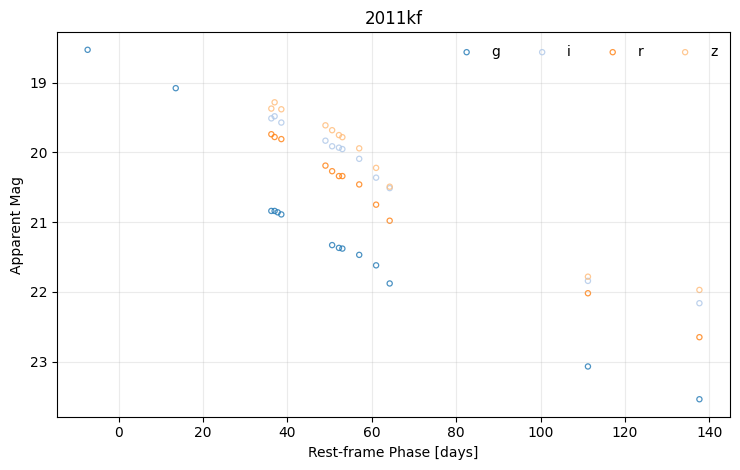

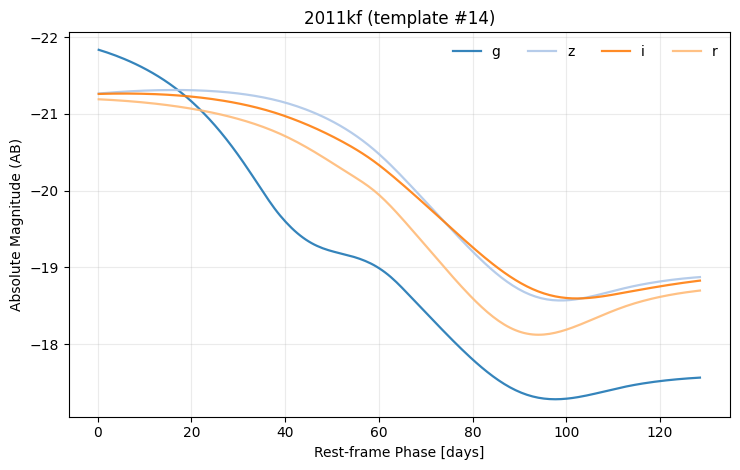

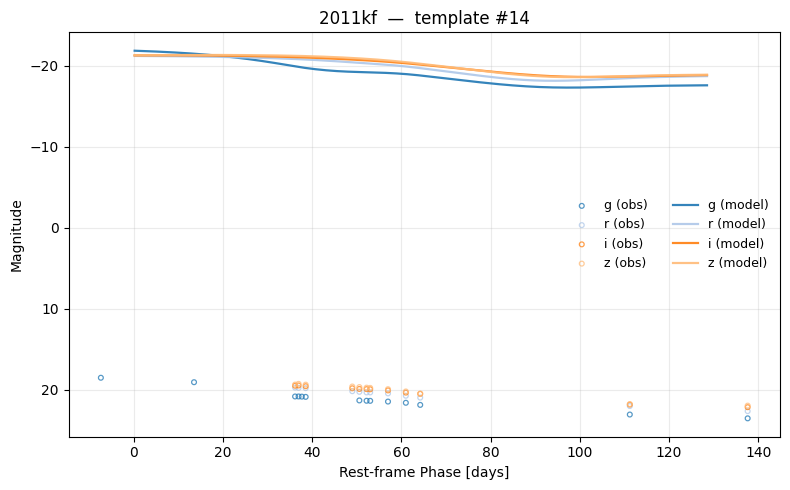

In [632]:
event = "2011kf"

# find the template index for this event
# find the correct (z, t0)
idx = slsn_metric.template_index_for_event(templates_file, "2011kf")
z, t0 = slsn_metric.get_event_z_t0("2011kf", inputs.params_table, per_event_csv_dir)

# 1) observations (name, not index)
slsn_metric.plot_event_obs("2011kf",
    per_event_dir=per_event_csv_dir, use_phase=True, z=z, t0=t0, scale_to_peak=False)


# 2) model curves (index)
slsn_metric.plot_event_model(
    templates_file,
    template_idx=idx
)

# 3) overlay obs + model (name + index)
slsn_metric.plot_event_obs_vs_model(
    "2011kf",
    per_event_dir=per_event_csv_dir,
    templates_file=templates_file,
    template_idx=idx,
    use_phase=True, z=z, t0=t0,
    bands=["g","r","i","z"],
    scale_to_peak=False,
)






# Diagnostics

In [634]:
# 1) What filters exist in 2011kf_cenwave.csv?
p = per_event_csv_dir / "2011kf_cenwave.csv"
df = pd.read_csv(p)
cols = {c.lower(): c for c in df.columns}
print(sorted(df[cols["filter"]].astype(str).unique()))

# 2) For a given template index, list the model bands it actually has:
obj = pickle.load(open(templates_file, "rb"))
tpl = obj["lightcurves"][idx]   # use the idx you computed for 2011kf
print(sorted([k for k,v in tpl.items() if isinstance(v, dict) and {"ph","mag"}<=set(v)]))

# 3) Which events have a 'C' band? 
names = obj.get("names", [f"tpl_{i}" for i in range(len(obj["lightcurves"]))])
has_C = [n for n, tpl in zip(names, obj["lightcurves"])
         if any(k == "C" and isinstance(v, dict) and {"ph","mag"} <= set(v)
                for k, v in tpl.items())]
print("Events with C:", has_C)



['g', 'i', 'r', 'z']
['g', 'i', 'r', 'z']
Events with C: ['2011ep', '2014bl', '2016ard', '2017dwh', '2018fd', '2018jfo', 'CSS140925', 'CSS160710']


[abs-from-templates] m_obs - (M_abs + DM) [mag]:
       N    median      mean       std
band                                  
g     14  0.040045  0.088936  0.167644
i     12  0.049063  0.085011  0.127937
r     12  0.066790  0.125476  0.225731
z     12  0.052189  0.074515  0.100884
Global median: 0.049859282826229645


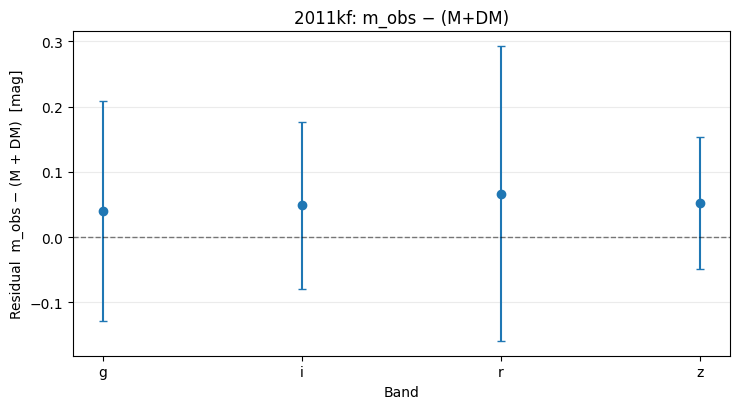

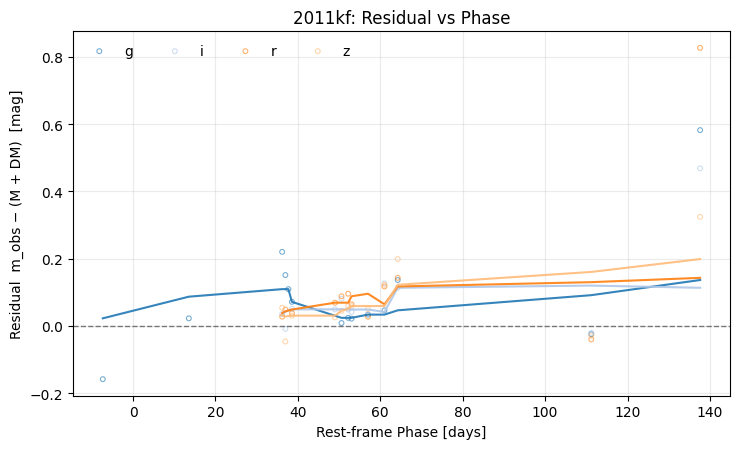

[internal] m_GP - (M_abs + DM) [mag]:
        N    median       std
band                         
g     220  0.060971  0.053215
i     220  0.029102  0.034308
r     220  0.029478  0.047050
z     220  0.023487  0.043087
Global median: 0.03624868364031997


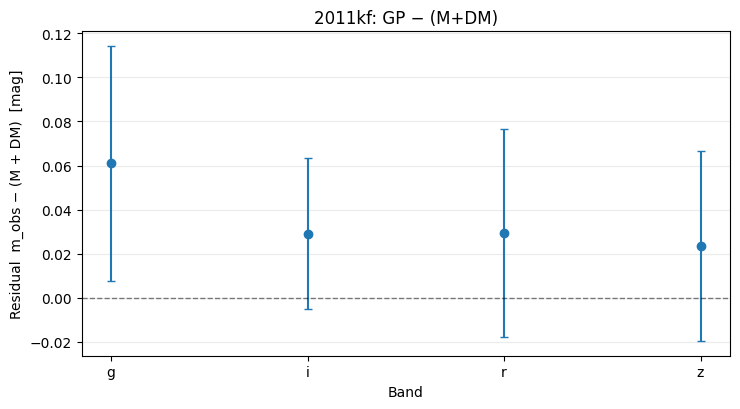

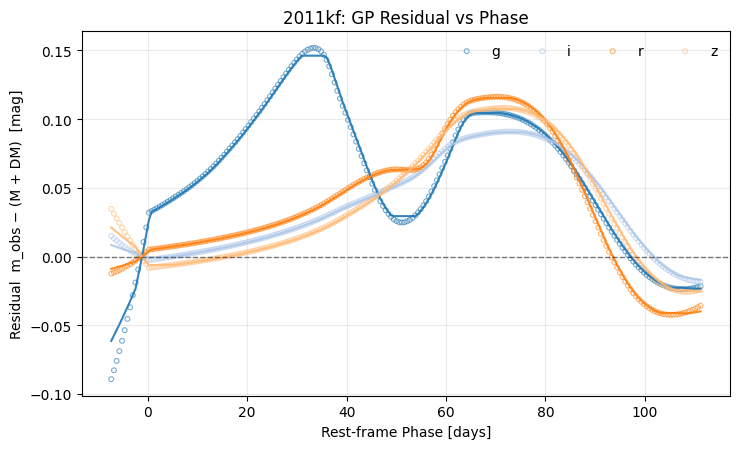

CSV bands: ['g', 'i', 'r', 'z']
Template bands: ['g', 'i', 'r', 'z']


In [635]:
# 1) Apparent vs (Abs + DM)
df_res = slsn_metric.diagnose_abs_from_templates(
    event, per_event_csv_dir, templates_file, idx,
    z=z, t0=t0, bands=["g","r","i","z"], return_with_phase=True, verbose=True
)
slsn_metric.plot_residuals(df_res, by_band=True, title=f"{event}: m_obs − (M+DM)")
slsn_metric.plot_residuals(df_res, vs_phase=True, title=f"{event}: Residual vs Phase")

# 2) Internal GP consistency
df_int = slsn_metric.diagnose_internal_consistency(
    event, per_event_csv_dir, templates_file, idx,
    z=z, t0=t0, n_time=220, verbose=True
)
slsn_metric.plot_residuals(df_int, by_band=True, title=f"{event}: GP − (M+DM)")
slsn_metric.plot_residuals(df_int, vs_phase=True, title=f"{event}: GP Residual vs Phase")

# Quick audits
print("CSV bands:", slsn_metric.list_event_bands(per_event_csv_dir, event))
print("Template bands:", slsn_metric.list_template_bands(templates_file, idx))

# Not yet

In [ ]:

# --- Population slicer (reuses your GRB machinery; templates are absolute-mag) ---
slicer = shared_utils.load_or_generate_population(
    use_extinction=use_extinction,
    lc_model=shared_lc_model,
    t_start=t_start, t_end=t_end,
    d_min=d_min, d_max=d_max, z_min=z_min, z_max=z_max,
    seed=42, num_lightcurves=None,  # read count from templates; not used
    gal_lat_cut=gal_lat_cut, rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop, make_debug_plots=make_debug_plots,
    use_kcorrect=use_kcorrect, k_correct_type=k_correct_type, k_correct_arg=k_correct_arg
)

# --- Run metrics (detect placeholder here; add more later if desired) ---
multi_metrics = slsn_metric.get_multi_metrics(shared_lc_model, include=['detect'],
                                              use_extinction=use_extinction,
                                              use_kcorrect=use_kcorrect,
                                              k_correct_type=k_correct_type,
                                              k_correct_arg=k_correct_arg)

# optional: diagnostics knobs (same as your GRB code)
for m in multi_metrics:
    if hasattr(m, "diag_store"):
        m.diag_store = False
        m.diag_sample_rate = 0.01
        m.diag_per_event_cap = 30
        m.diag_min_snr = 3
        m.diag_max_mag = None

# quick detect run (produces ObsRecords_*.csv like GRB flow)
df_obs = shared_utils.run_detect(
    slsn_metric, slicer, cadences, shared_lc_model, db_dir, storage_dir, df_file,
    use_extinction=use_extinction, use_kcorrect=use_kcorrect,
    k_correct_type=k_correct_type, k_correct_arg=k_correct_arg,
    ignore_triples=ignore_triples, debug=True, plot=True, clean_temp=clean_temp
)

# multi-metric summary table (works even with only 'detect' present)
summary_df = shared_utils.run_multi_metrics(
    multi_metrics, slicer, cadences, shared_lc_model,
    db_dir, storage_dir, summary_filename=summary_filename,
    ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction
)
summary_df
